# Imports 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from src.setup import get_base
from src.feature_engineering import engineer_features, engineer_features2, engineer_features_combined, engineer_features_optimized, engineer_features_focused
from sklearn.preprocessing import StandardScaler
from src.clustering import SegmentationPipeline

# Data

In [2]:
df = get_base()
df.head()

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,...,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_price_per_room_night_usd
0,101486-6d053e0f51884dddb339416c86d5b3a9,101486,NaN,2023-07-18 09:35:00,2023-07-18 09:35:22,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
1,101486-6de2ac91a8c24619a69a3d3ae7c28d61,101486,NaN,2023-03-21 10:16:00,2023-03-21 10:18:38,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
2,101486-7e8b450e5fe94345bd6c1ae9f479f073,101486,NaN,2023-02-11 17:05:00,2023-02-11 17:07:58,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
3,101486-9e7d5ccc7e034bf7b7a5ad2f3befbe13,101486,NaN,2023-05-30 20:42:00,2023-05-30 20:44:15,True,False,0.1,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
4,101486-be6d02b11839441aa4107044d095cb99,101486,NaN,2023-03-06 21:50:00,2023-03-06 21:50:53,False,False,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN


# Features

In [3]:
df_features = engineer_features2(df)
df_features.head()

/Users/kiko/Desktop/github/traveltide/src/feature_engineering.py:186: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_features["flight_discount_ratio"] = grouped.apply(
/Users/kiko/Desktop/github/traveltide/src/feature_engineering.py:214: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_features["flight_hotel_combo_ratio"] = grouped.apply(


,age,gender,married,has_children,n_unique_destinations,avg_flight_fare_usd,total_flight_fare_usd,total_flights_booked,total_hotels_booked,total_flight_discount,avg_flight_discount,flight_discount_ratio,avg_flight_discount_percentage,avg_checked_bags,total_cancellations,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio
user_id,,,,,,,,,,,,,,,,,,
23557,66,0.0,1,0,0,0.000,0.00,0,2,0,0.000,0.000000,0.000000,0.000000,0,0.00,0.000,1.000000
94883,53,0.0,1,0,2,432.045,864.09,2,2,0,0.000,0.000000,0.000000,0.500000,0,0.00,0.250,0.500000
101486,52,0.0,1,1,1,189.910,189.91,1,2,2,0.250,1.999998,0.010531,0.000000,0,0.00,0.125,0.666666
101961,45,0.0,1,0,5,248.532,1242.66,5,5,2,0.250,0.400000,0.001609,0.400000,0,0.00,0.625,0.500000
106907,46,0.0,1,1,1,13902.060,27804.12,2,2,1,0.125,0.500000,0.000036,4.999998,1,0.25,0.250,0.500000


# Clustering

In [4]:
pipe = SegmentationPipeline(variance_threshold=0.95, max_clusters=10)

In [5]:
features_scaled, df_clean = pipe.prepare_features(df_features)

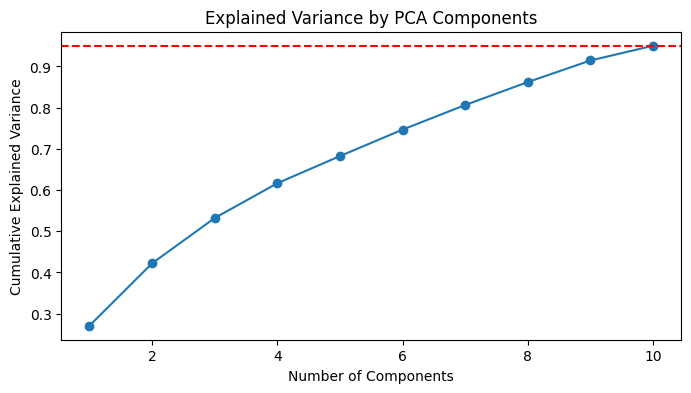

In [6]:
components, pca, explained_var = pipe.run_pca(features_scaled)
pipe.plot_explained_variance()

KMeans with 2 clusters: 0.1709
KMeans with 3 clusters: 0.3298
KMeans with 4 clusters: 0.1773
KMeans with 5 clusters: 0.1869
KMeans with 6 clusters: 0.1778
KMeans with 7 clusters: 0.1840
KMeans with 8 clusters: 0.1977
KMeans with 9 clusters: 0.1884
KMeans with 10 clusters: 0.1808


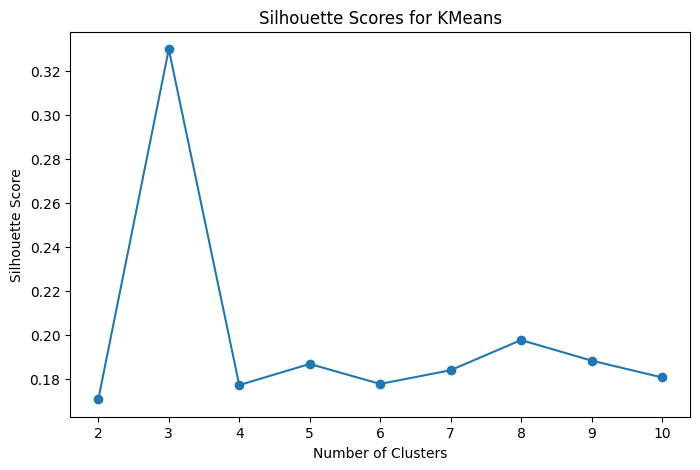

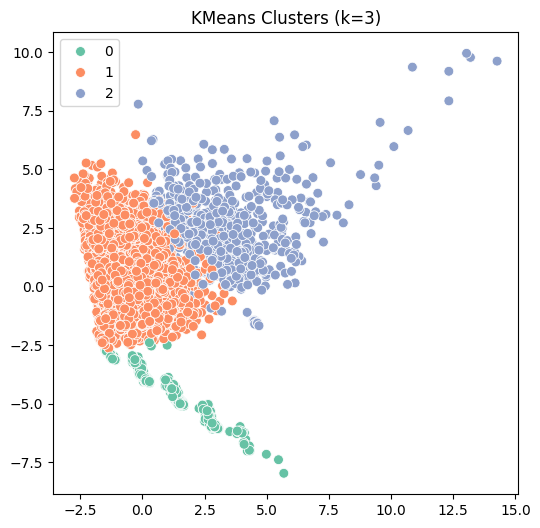

In [7]:
model_auto, scores_auto = pipe.optimized_kmeans_clustering()
pipe.plot_scores()
pipe.plot_clusters()

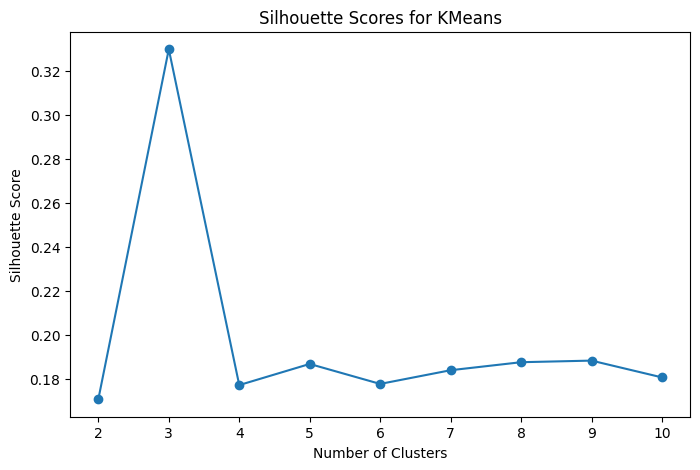

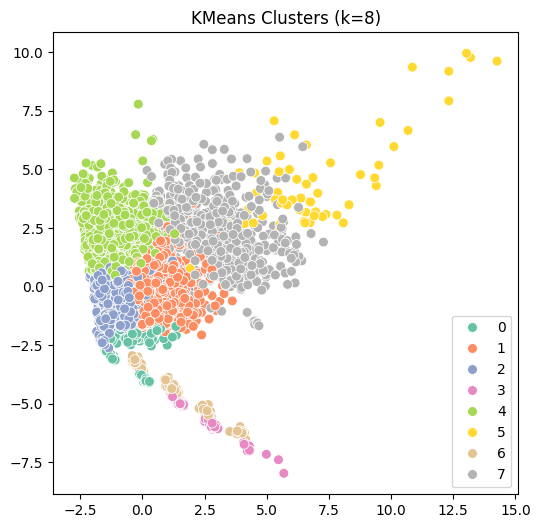

In [8]:
model_fixed, scores_fixed = pipe.kmeans_clustering(n_clusters=8)
pipe.plot_scores()
pipe.plot_clusters()

In [9]:
df_clusters = pipe.assign_clusters(df_features)

# Report
summary = pipe.cluster_summary(df_clusters)
summary.to_csv('../report/summary_clusters.csv')

display(summary)

age                         gender                         ...  \
              mean median min max count      mean median  min  max count  ...   
cluster                                                                   ...   
0        40.115702   34.0  18  90   363  0.123967    0.0  0.0  1.0   363  ...   
1        43.740268   44.0  18  80  1490  0.112081    0.0  0.0  1.0  1490  ...   
2        42.380548   43.0  18  87  1532  0.124674    0.0  0.0  1.0  1532  ...   
3        39.864130   34.5  18  82   184  0.114130    0.0  0.0  1.0   184  ...   
4        45.073359   45.0  18  68  1554  0.102960    0.0  0.0  1.0  1554  ...   
5        41.967213   42.0  19  73    61  0.180328    0.0  0.0  1.0    61  ...   
6        41.003650   33.5  18  86   274  0.083942    0.0  0.0  1.0   274  ...   
7        42.000000   43.0  18  86   540  0.142593    0.0  0.0  1.0   540  ...   

        flight_hotel_combo_ratio                             \
                            mean median    min    max count   
cluster                                                       
0                       0.000000  0.000  0.000  0.000   363   
1                       0.226040  0.250  0.000  0.625  1490   
2                       0.175418  0.125  0.000  0.375  1532   
3                       0.000000  0.000  0.000  0.000   184   
4                       0.447160  0.400  0.125  1.000  1554   
5                       0.235077  0.250  0.000  0.625    61   
6                       0.000000  0.000  0.000  0.000   274   
7                       0.380444  0.375  0.100  0.875   540   

        hotel_booking_ratio                                      
                       mean    median       min       max count  
cluster                                                          
0                  0.000000  0.000000  0.000000  0.000000   363  
1                  0.512120  0.500000  0.000000  0.800000  1490  
2                  0.540641  0.500000  0.000000  1.000000  1532  
3                  0.010870  0.000000  0.000000  0.999999   184  
4                  0.496391  0.500000  0.200000  0.666667  1554  
5                  0.457081  0.500000  0.250000  0.800000    61  
6                  0.999999  0.999999  0.999999  1.000000   274  
7                  0.487094  0.500000  0.250000  0.800000   540  

[8 rows x 90 columns]

In [10]:
# Cluster Means
means = pipe.cluster_means(df_clusters)
display(means)

,age,gender,married,has_children,n_unique_destinations,avg_flight_fare_usd,total_flight_fare_usd,total_flights_booked,total_hotels_booked,total_flight_discount,avg_flight_discount,flight_discount_ratio,avg_flight_discount_percentage,avg_checked_bags,total_cancellations,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio
cluster,,,,,,,,,,,,,,,,,,
0,40.115702,0.123967,0.399449,0.336088,0.256198,112.422259,125.547355,0.258953,0.000000,0.779614,0.096191,4.848488e+05,4.848485e+05,0.126722,0.000000,0.000000,0.000000,0.000000
1,43.740268,0.112081,0.475168,0.348993,2.038926,446.724712,928.064409,2.122819,2.250336,2.534228,0.309720,1.443467e+00,6.350137e-03,0.571331,0.000000,0.000000,0.226040,0.512120
2,42.380548,0.124674,0.460836,0.359661,1.632507,437.837757,775.683557,1.699739,1.894909,0.578329,0.071184,3.864227e-01,1.572916e-03,0.562391,0.000000,0.000000,0.175418,0.540641
3,39.864130,0.114130,0.391304,0.309783,0.000000,0.000000,0.000000,0.000000,0.010870,2.413043,0.294257,2.413043e+06,2.413043e+06,0.000000,0.000000,0.000000,0.000000,0.010870
4,45.073359,0.102960,0.413771,0.254826,3.749678,439.394378,1760.118546,4.013514,3.969112,1.035393,0.126097,2.636493e-01,7.461947e-04,0.564251,0.002574,0.000162,0.447160,0.496391
5,41.967213,0.180328,0.786885,0.672131,1.803279,5438.038500,12958.658033,2.622951,2.278689,2.147541,0.265021,9.027318e-01,1.935356e-04,2.114480,0.819672,0.174246,0.235077,0.457081
6,41.003650,0.083942,0.408759,0.372263,0.000000,0.000000,0.000000,0.000000,1.266423,1.751825,0.213279,1.751825e+06,1.751825e+06,0.000000,0.000000,0.000000,0.000000,0.999999
7,42.000000,0.142593,0.385185,0.312963,2.468519,720.985920,2436.303056,3.620370,3.518519,2.342593,0.284226,7.589966e-01,4.259259e+04,0.612703,1.025926,0.166527,0.380444,0.487094


In [16]:
df_clusters = pipe.assign_clusters(df_features)

# Überblick
summary = pipe.cluster_summary(df_clusters)
summary.to_csv('../report/summary_clusters.csv')


display(summary)
print(summary)

# Einfachere Übersicht: Cluster-Mittelwerte
means = pipe.cluster_means(df_clusters)
display(means)

age                         gender                         ...  \
              mean median min max count      mean median  min  max count  ...   
cluster                                                                   ...   
0        40.115702   34.0  18  90   363  0.123967    0.0  0.0  1.0   363  ...   
1        43.740268   44.0  18  80  1490  0.112081    0.0  0.0  1.0  1490  ...   
2        42.380548   43.0  18  87  1532  0.124674    0.0  0.0  1.0  1532  ...   
3        39.864130   34.5  18  82   184  0.114130    0.0  0.0  1.0   184  ...   
4        45.073359   45.0  18  68  1554  0.102960    0.0  0.0  1.0  1554  ...   
5        41.967213   42.0  19  73    61  0.180328    0.0  0.0  1.0    61  ...   
6        41.003650   33.5  18  86   274  0.083942    0.0  0.0  1.0   274  ...   
7        42.000000   43.0  18  86   540  0.142593    0.0  0.0  1.0   540  ...   

        flight_hotel_combo_ratio                             \
                            mean median    min    max count   
cluster                                                       
0                       0.000000  0.000  0.000  0.000   363   
1                       0.226040  0.250  0.000  0.625  1490   
2                       0.175418  0.125  0.000  0.375  1532   
3                       0.000000  0.000  0.000  0.000   184   
4                       0.447160  0.400  0.125  1.000  1554   
5                       0.235077  0.250  0.000  0.625    61   
6                       0.000000  0.000  0.000  0.000   274   
7                       0.380444  0.375  0.100  0.875   540   

        hotel_booking_ratio                                      
                       mean    median       min       max count  
cluster                                                          
0                  0.000000  0.000000  0.000000  0.000000   363  
1                  0.512120  0.500000  0.000000  0.800000  1490  
2                  0.540641  0.500000  0.000000  1.000000  1532  
3                  0.010870  0.000000  0.000000  0.999999   184  
4                  0.496391  0.500000  0.200000  0.666667  1554  
5                  0.457081  0.500000  0.250000  0.800000    61  
6                  0.999999  0.999999  0.999999  1.000000   274  
7                  0.487094  0.500000  0.250000  0.800000   540  

[8 rows x 90 columns]

               age                         gender                         ...  \
              mean median min max count      mean median  min  max count  ...   
cluster                                                                   ...   
0        40.115702   34.0  18  90   363  0.123967    0.0  0.0  1.0   363  ...   
1        43.740268   44.0  18  80  1490  0.112081    0.0  0.0  1.0  1490  ...   
2        42.380548   43.0  18  87  1532  0.124674    0.0  0.0  1.0  1532  ...   
3        39.864130   34.5  18  82   184  0.114130    0.0  0.0  1.0   184  ...   
4        45.073359   45.0  18  68  1554  0.102960    0.0  0.0  1.0  1554  ...   
5        41.967213   42.0  19  73    61  0.180328    0.0  0.0  1.0    61  ...   
6        41.003650   33.5  18  86   274  0.083942    0.0  0.0  1.0   274  ...   
7        42.000000   43.0  18  86   540  0.142593    0.0  0.0  1.0   540  ...   

        flight_hotel_combo_ratio                             \
                            mean median    mi

,age,gender,married,has_children,n_unique_destinations,avg_flight_fare_usd,total_flight_fare_usd,total_flights_booked,total_hotels_booked,total_flight_discount,avg_flight_discount,flight_discount_ratio,avg_flight_discount_percentage,avg_checked_bags,total_cancellations,cancellation_rate,flight_hotel_combo_ratio,hotel_booking_ratio
cluster,,,,,,,,,,,,,,,,,,
0,40.115702,0.123967,0.399449,0.336088,0.256198,112.422259,125.547355,0.258953,0.000000,0.779614,0.096191,4.848488e+05,4.848485e+05,0.126722,0.000000,0.000000,0.000000,0.000000
1,43.740268,0.112081,0.475168,0.348993,2.038926,446.724712,928.064409,2.122819,2.250336,2.534228,0.309720,1.443467e+00,6.350137e-03,0.571331,0.000000,0.000000,0.226040,0.512120
2,42.380548,0.124674,0.460836,0.359661,1.632507,437.837757,775.683557,1.699739,1.894909,0.578329,0.071184,3.864227e-01,1.572916e-03,0.562391,0.000000,0.000000,0.175418,0.540641
3,39.864130,0.114130,0.391304,0.309783,0.000000,0.000000,0.000000,0.000000,0.010870,2.413043,0.294257,2.413043e+06,2.413043e+06,0.000000,0.000000,0.000000,0.000000,0.010870
4,45.073359,0.102960,0.413771,0.254826,3.749678,439.394378,1760.118546,4.013514,3.969112,1.035393,0.126097,2.636493e-01,7.461947e-04,0.564251,0.002574,0.000162,0.447160,0.496391
5,41.967213,0.180328,0.786885,0.672131,1.803279,5438.038500,12958.658033,2.622951,2.278689,2.147541,0.265021,9.027318e-01,1.935356e-04,2.114480,0.819672,0.174246,0.235077,0.457081
6,41.003650,0.083942,0.408759,0.372263,0.000000,0.000000,0.000000,0.000000,1.266423,1.751825,0.213279,1.751825e+06,1.751825e+06,0.000000,0.000000,0.000000,0.000000,0.999999
7,42.000000,0.142593,0.385185,0.312963,2.468519,720.985920,2436.303056,3.620370,3.518519,2.342593,0.284226,7.589966e-01,4.259259e+04,0.612703,1.025926,0.166527,0.380444,0.487094


/var/folders/n0/4xfyfrnd1wj35c4v3fsvg9sh0000gn/T/ipykernel_37587/225331747.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clusters, x='cluster', y='age', palette=palette)


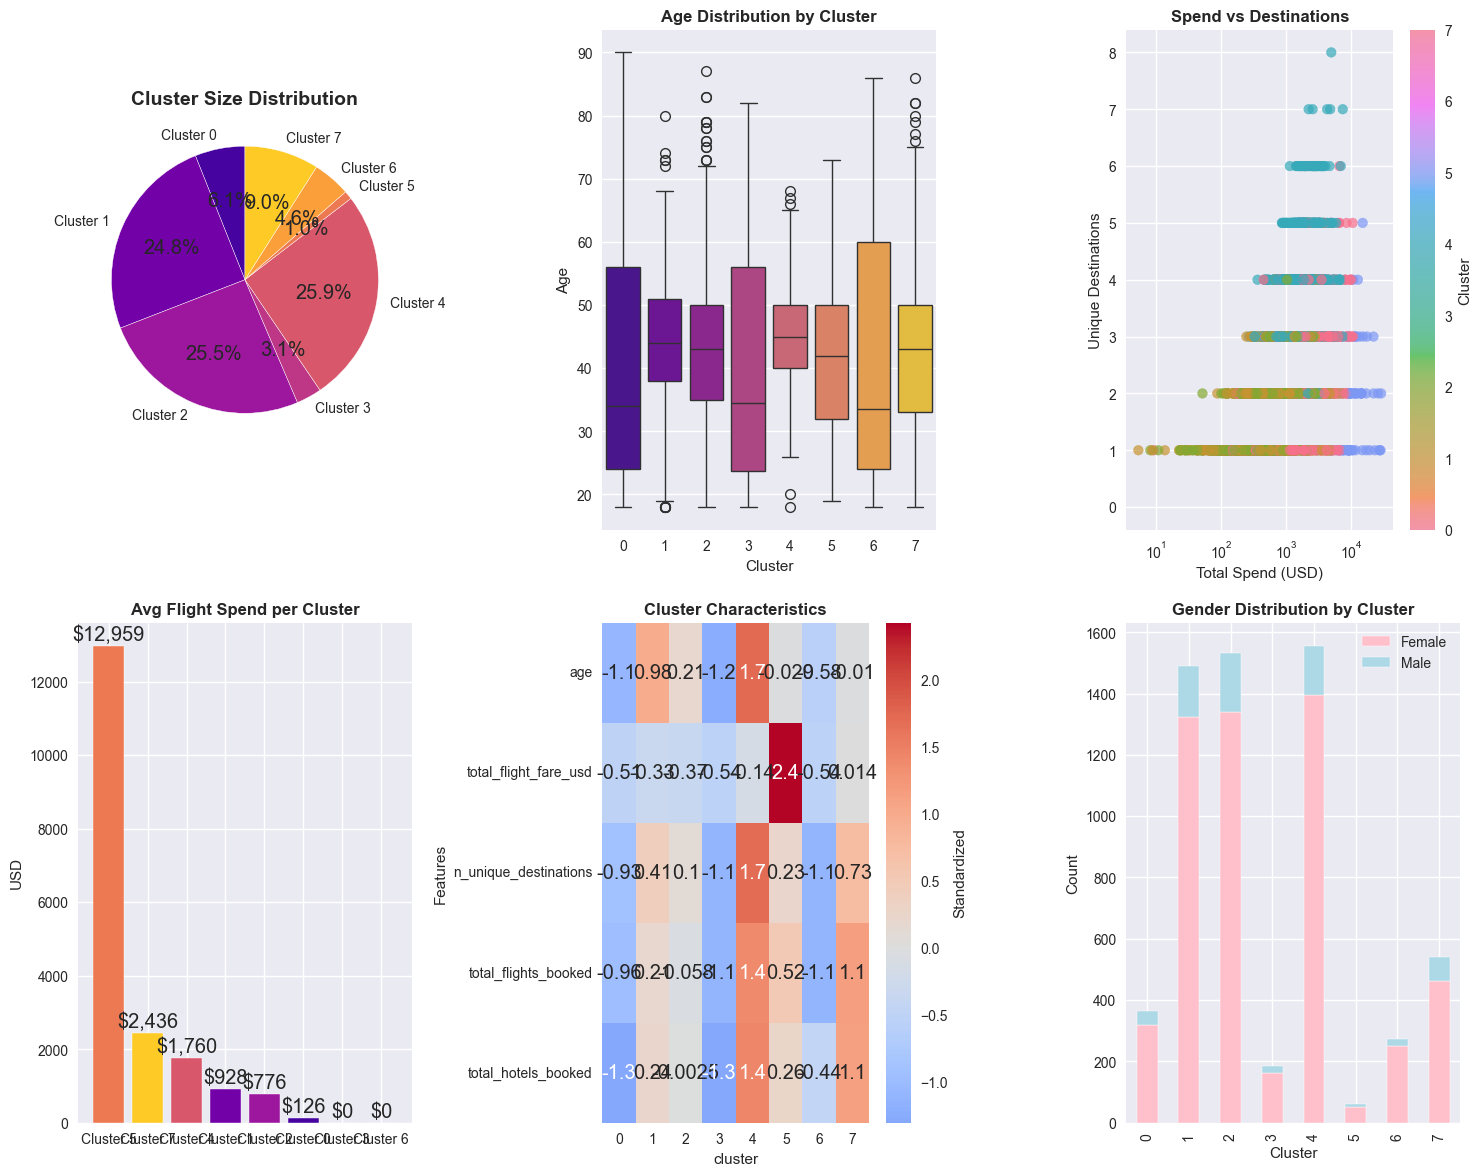

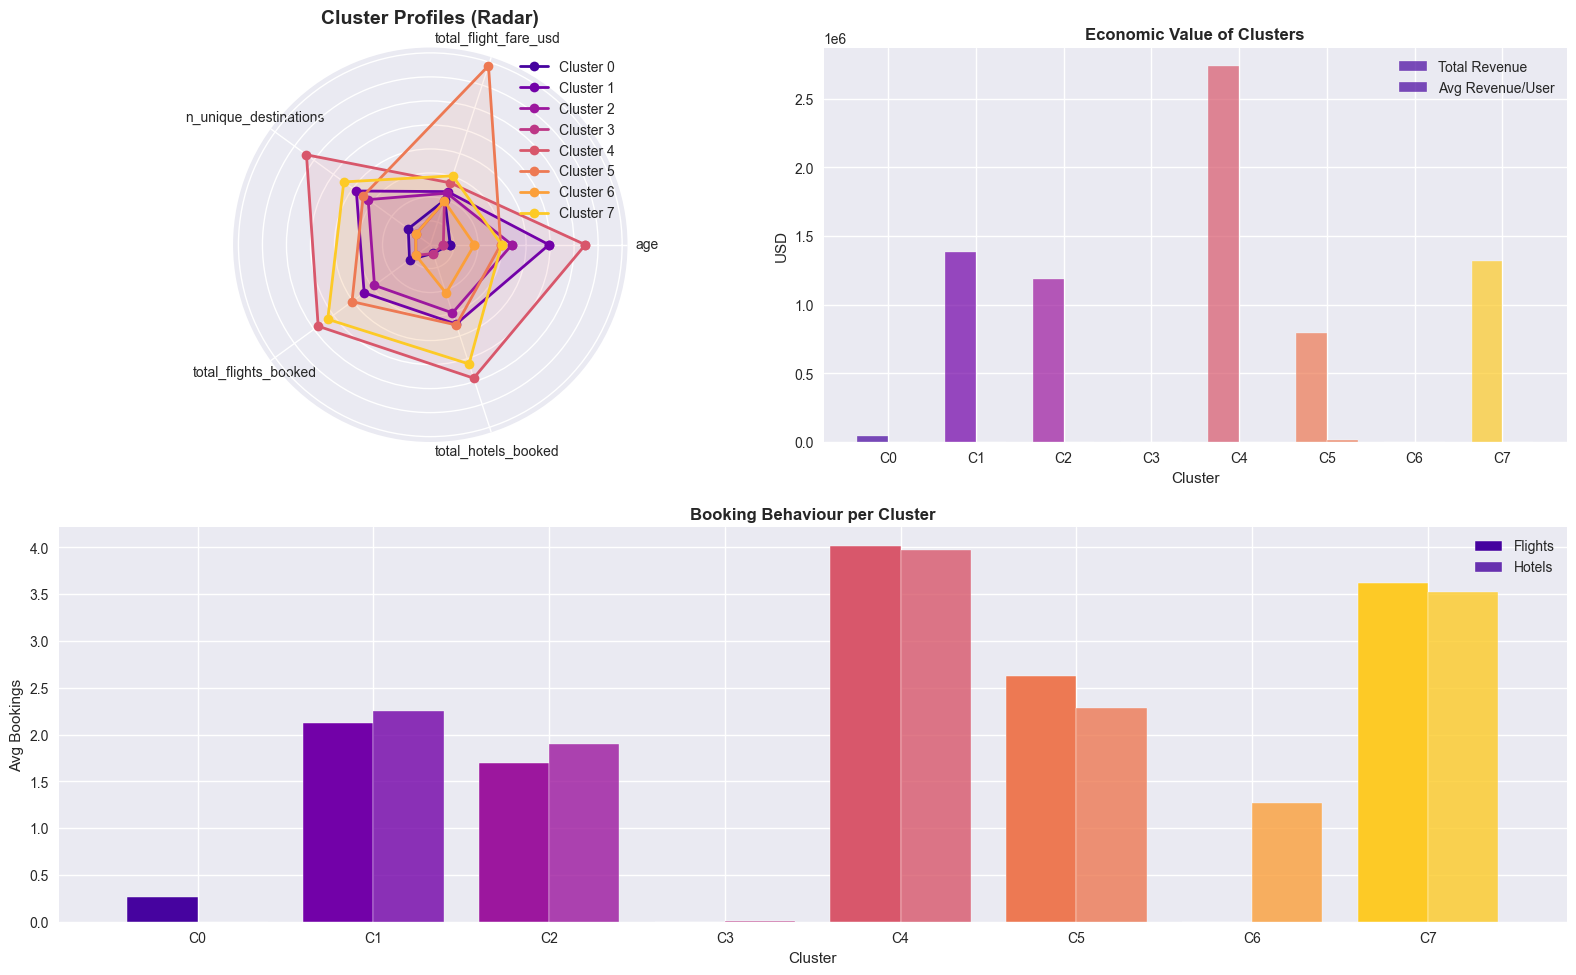

📊 CLUSTER STORYTELLING

🏷️  Cluster 0 (n=363)
   👥 Avg Age: 40.1
   💰 Avg Spend: $126
   ✈️  Flights: 0.3
   🏨 Hotels: 0.0
   🎯 Recommended Perk: Comfort packages, bundle flight+hotel

🏷️  Cluster 1 (n=1,490)
   👥 Avg Age: 43.7
   💰 Avg Spend: $928
   ✈️  Flights: 2.1
   🏨 Hotels: 2.3
   🎯 Recommended Perk: Budget options, special discounts

🏷️  Cluster 2 (n=1,532)
   👥 Avg Age: 42.4
   💰 Avg Spend: $776
   ✈️  Flights: 1.7
   🏨 Hotels: 1.9
   🎯 Recommended Perk: Frequent flyer program, free checked bag

🏷️  Cluster 3 (n=184)
   👥 Avg Age: 39.9
   💰 Avg Spend: $0
   ✈️  Flights: 0.0
   🏨 Hotels: 0.0
   🎯 Recommended Perk: Hotel perks like free meals or spa access

🏷️  Cluster 4 (n=1,554)
   👥 Avg Age: 45.1
   💰 Avg Spend: $1,760
   ✈️  Flights: 4.0
   🏨 Hotels: 4.0
   🎯 Recommended Perk: Business perks: flexible cancellation, lounge access

🏷️  Cluster 5 (n=61)
   👥 Avg Age: 42.0
   💰 Avg Spend: $12,959
   ✈️  Flights: 2.6
   🏨 Hotels: 2.3
   🎯 Recommended Perk: Luxury services, premiu

In [21]:
# ------------------------------------------------
# 1. Setup & Styling
# ------------------------------------------------
plt.style.use('seaborn-v0_8')

# husl-Palette für alle Plots
n_clusters = df_clusters['cluster'].nunique()
palette = sns.color_palette("plasma", n_clusters)

# Farben pro Cluster vorbereiten
cluster_colors = df_clusters['cluster'].map(dict(zip(range(n_clusters), palette)))

# ------------------------------------------------
# 2. Cluster Sizes (Pie Chart)
# ------------------------------------------------
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
cluster_sizes = df_clusters['cluster'].value_counts().sort_index()
plt.pie(cluster_sizes.values,
        labels=[f'Cluster {i}' for i in cluster_sizes.index],
        autopct='%1.1f%%',
        colors=palette,
        startangle=90)
plt.title('Cluster Size Distribution', fontsize=14, fontweight='bold')

# ------------------------------------------------
# 3. Age Distribution (Boxplot)
# ------------------------------------------------
plt.subplot(2, 3, 2)
sns.boxplot(data=df_clusters, x='cluster', y='age', palette=palette)
plt.title('Age Distribution by Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Age')

# ------------------------------------------------
# 4. Spend vs Destinations (Scatter Plot)
# ------------------------------------------------
plt.subplot(2, 3, 3)

scatter = plt.scatter(
    df_clusters['total_flight_fare_usd'],
    df_clusters['n_unique_destinations'],
    c=df_clusters['cluster'],  # Cluster als Farben
    cmap=sns.color_palette("husl", n_clusters, as_cmap=True),
    alpha=0.7
)

plt.xlabel('Total Spend (USD)')
plt.ylabel('Unique Destinations')
plt.title('Spend vs Destinations', fontweight='bold')
plt.xscale('log')

# Colorbar richtig an das Scatter binden
plt.colorbar(scatter, label="Cluster")

# ------------------------------------------------
# 5. Avg Spend per Cluster (Bar Chart)
# ------------------------------------------------
plt.subplot(2, 3, 4)
cluster_means = df_clusters.groupby('cluster')['total_flight_fare_usd'].mean().sort_values(ascending=False)
bars = plt.bar(range(len(cluster_means)), cluster_means.values,
               color=[palette[i] for i in cluster_means.index])
plt.xticks(range(len(cluster_means)), [f'Cluster {i}' for i in cluster_means.index])
plt.title('Avg Flight Spend per Cluster', fontweight='bold')
plt.ylabel('USD')
for bar, value in zip(bars, cluster_means.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'${value:,.0f}', ha='center', va='bottom')

# ------------------------------------------------
# 6. Heatmap of Key Features
# ------------------------------------------------
plt.subplot(2, 3, 5)
important_features = ['age', 'total_flight_fare_usd', 'n_unique_destinations',
                     'total_flights_booked', 'total_hotels_booked']
cluster_summary = df_clusters.groupby('cluster')[important_features].mean()
cluster_summary_norm = (cluster_summary - cluster_summary.mean()) / cluster_summary.std()
sns.heatmap(cluster_summary_norm.T, annot=True, cmap='coolwarm', center=0,
            cbar_kws={'label': 'Standardized'})
plt.title('Cluster Characteristics', fontweight='bold')
plt.ylabel('Features')

# ------------------------------------------------
# 7. Gender Distribution (Stacked Bar)
# ------------------------------------------------
plt.subplot(2, 3, 6)
gender_by_cluster = pd.crosstab(df_clusters['cluster'], df_clusters['gender'])
gender_by_cluster.plot(kind='bar', stacked=True, color=['pink', 'lightblue'], ax=plt.gca())
plt.title('Gender Distribution by Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(['Female', 'Male'])

plt.tight_layout()
plt.show()

# ------------------------------------------------
# 8. Detailed Profiles (Radar + Revenue + Booking)
# ------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig)

# Radar Chart
ax1 = fig.add_subplot(gs[0, 0], polar=True)
features_for_radar = ['age', 'total_flight_fare_usd', 'n_unique_destinations',
                      'total_flights_booked', 'total_hotels_booked']
radar_data = cluster_summary_norm[features_for_radar]
angles = np.linspace(0, 2*np.pi, len(features_for_radar), endpoint=False).tolist()
angles += angles[:1]

for cluster_idx in radar_data.index:
    values = radar_data.loc[cluster_idx].values.tolist()
    values += values[:1]
    ax1.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_idx}',
             color=palette[cluster_idx])
    ax1.fill(angles, values, alpha=0.1, color=palette[cluster_idx])

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(features_for_radar)
ax1.set_yticklabels([])
ax1.set_title('Cluster Profiles (Radar)', fontweight='bold', size=14)
ax1.legend()

# Revenue
ax2 = fig.add_subplot(gs[0, 1])
total_rev = df_clusters.groupby('cluster')['total_flight_fare_usd'].sum()
avg_rev = df_clusters.groupby('cluster')['total_flight_fare_usd'].mean()
x = np.arange(len(total_rev))
width = 0.35
bars1 = ax2.bar(x, total_rev.values, width, label='Total Revenue', alpha=0.7,
                color=[palette[i] for i in total_rev.index])
bars2 = ax2.bar(x+width, avg_rev.values, width, label='Avg Revenue/User', alpha=0.7,
                color=[palette[i] for i in avg_rev.index])
ax2.set_xlabel('Cluster')
ax2.set_ylabel('USD')
ax2.set_title('Economic Value of Clusters', fontweight='bold')
ax2.set_xticks(x + width/2)
ax2.set_xticklabels([f'C{i}' for i in total_rev.index])
ax2.legend()

# Booking Behaviour
ax3 = fig.add_subplot(gs[1, :])
booking_data = df_clusters.groupby('cluster')[['total_flights_booked','total_hotels_booked']].mean()
x = np.arange(len(booking_data))
bars3 = ax3.bar(x-0.2, booking_data['total_flights_booked'], 0.4, label='Flights',
                color=[palette[i] for i in booking_data.index])
bars4 = ax3.bar(x+0.2, booking_data['total_hotels_booked'], 0.4, label='Hotels',
                alpha=0.8, color=[palette[i] for i in booking_data.index])
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Avg Bookings')
ax3.set_title('Booking Behaviour per Cluster', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'C{i}' for i in booking_data.index])
ax3.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------
# 9. Storytelling & Recommendations
# ------------------------------------------------
def get_cluster_recommendation(cluster):
    recs = {
        0: "Comfort packages, bundle flight+hotel",
        1: "Budget options, special discounts",
        2: "Frequent flyer program, free checked bag",
        3: "Hotel perks like free meals or spa access",
        4: "Business perks: flexible cancellation, lounge access",
        5: "Luxury services, premium concierge",
        6: "Light travelers: welcome discount",
        7: "Family bundles (hotel + flights)"
    }
    return recs.get(cluster, "Further analysis needed")

print("="*60)
print("📊 CLUSTER STORYTELLING")
print("="*60)
for cluster in sorted(df_clusters['cluster'].unique()):
    cdata = df_clusters[df_clusters['cluster'] == cluster]
    print(f"\n🏷️  Cluster {cluster} (n={len(cdata):,})")
    print(f"   👥 Avg Age: {cdata['age'].mean():.1f}")
    print(f"   💰 Avg Spend: ${cdata['total_flight_fare_usd'].mean():,.0f}")
    print(f"   ✈️  Flights: {cdata['total_flights_booked'].mean():.1f}")
    print(f"   🏨 Hotels: {cdata['total_hotels_booked'].mean():.1f}")
    print(f"   🎯 Recommended Perk: {get_cluster_recommendation(cluster)}")

In [22]:
# ------------------------------------------------
# 10. Cluster Profiling & Perk Assignment
# ------------------------------------------------

# Define perk logic (storytelling + perk)
def assign_perk(cluster_stats):
    """Assign a perk based on cluster characteristics."""
    if cluster_stats['total_flight_fare_usd'] > 8000:
        return "💎 Premium Lounge & Concierge Service"
    elif cluster_stats['total_flight_fare_usd'] > 2000:
        return "🧳 Free Checked Bag"
    elif cluster_stats['hotel_booking_ratio'] > 0.5:
        return "🏨 Free Hotel Night with Flight"
    elif cluster_stats['cancellation_rate'] > 0.2:
        return "🔄 No Cancellation Fees"
    elif cluster_stats['n_unique_destinations'] > 3:
        return "🌍 Exclusive Discounts on Destinations"
    else:
        return "🎁 10% Welcome Discount"

# Calculate mean stats per cluster
cluster_profiles = df_clusters.groupby("cluster").mean()

# Add perks
cluster_profiles["perk"] = cluster_profiles.apply(assign_perk, axis=1)

# ------------------------------------------------
# 11. Reporting for Storytelling
# ------------------------------------------------
print("="*70)
print("📊 CLUSTER STORYTELLING & PERKS")
print("="*70)

for cluster in sorted(df_clusters['cluster'].unique()):
    cdata = df_clusters[df_clusters['cluster'] == cluster]
    stats = cluster_profiles.loc[cluster]

    print(f"\n🏷️  Cluster {cluster} (n={len(cdata):,})")
    print(f"   👥 Avg Age: {cdata['age'].mean():.1f}")
    print(f"   ✈️ Avg Flights Booked: {cdata['total_flights_booked'].mean():.1f}")
    print(f"   🏨 Avg Hotels Booked: {cdata['total_hotels_booked'].mean():.1f}")
    print(f"   💰 Avg Spend: ${cdata['total_flight_fare_usd'].mean():,.0f}")
    print(f"   🌍 Unique Destinations: {cdata['n_unique_destinations'].mean():.1f}")
    print(f"   🚹 Gender Split (Male %): {100*cdata['gender'].mean():.1f}%")
    print(f"   🎯 Recommended Perk: {stats['perk']}")

# ------------------------------------------------
# 12. Optional: Export Cluster Profiles
# ------------------------------------------------
cluster_profiles.to_csv("../report/cluster_profiles_with_perks.csv", index=True)

📊 CLUSTER STORYTELLING & PERKS

🏷️  Cluster 0 (n=363)
   👥 Avg Age: 40.1
   ✈️ Avg Flights Booked: 0.3
   🏨 Avg Hotels Booked: 0.0
   💰 Avg Spend: $126
   🌍 Unique Destinations: 0.3
   🚹 Gender Split (Male %): 12.4%
   🎯 Recommended Perk: 🎁 10% Welcome Discount

🏷️  Cluster 1 (n=1,490)
   👥 Avg Age: 43.7
   ✈️ Avg Flights Booked: 2.1
   🏨 Avg Hotels Booked: 2.3
   💰 Avg Spend: $928
   🌍 Unique Destinations: 2.0
   🚹 Gender Split (Male %): 11.2%
   🎯 Recommended Perk: 🏨 Free Hotel Night with Flight

🏷️  Cluster 2 (n=1,532)
   👥 Avg Age: 42.4
   ✈️ Avg Flights Booked: 1.7
   🏨 Avg Hotels Booked: 1.9
   💰 Avg Spend: $776
   🌍 Unique Destinations: 1.6
   🚹 Gender Split (Male %): 12.5%
   🎯 Recommended Perk: 🏨 Free Hotel Night with Flight

🏷️  Cluster 3 (n=184)
   👥 Avg Age: 39.9
   ✈️ Avg Flights Booked: 0.0
   🏨 Avg Hotels Booked: 0.0
   💰 Avg Spend: $0
   🌍 Unique Destinations: 0.0
   🚹 Gender Split (Male %): 11.4%
   🎯 Recommended Perk: 🎁 10% Welcome Discount

🏷️  Cluster 4 (n=1,554)
  

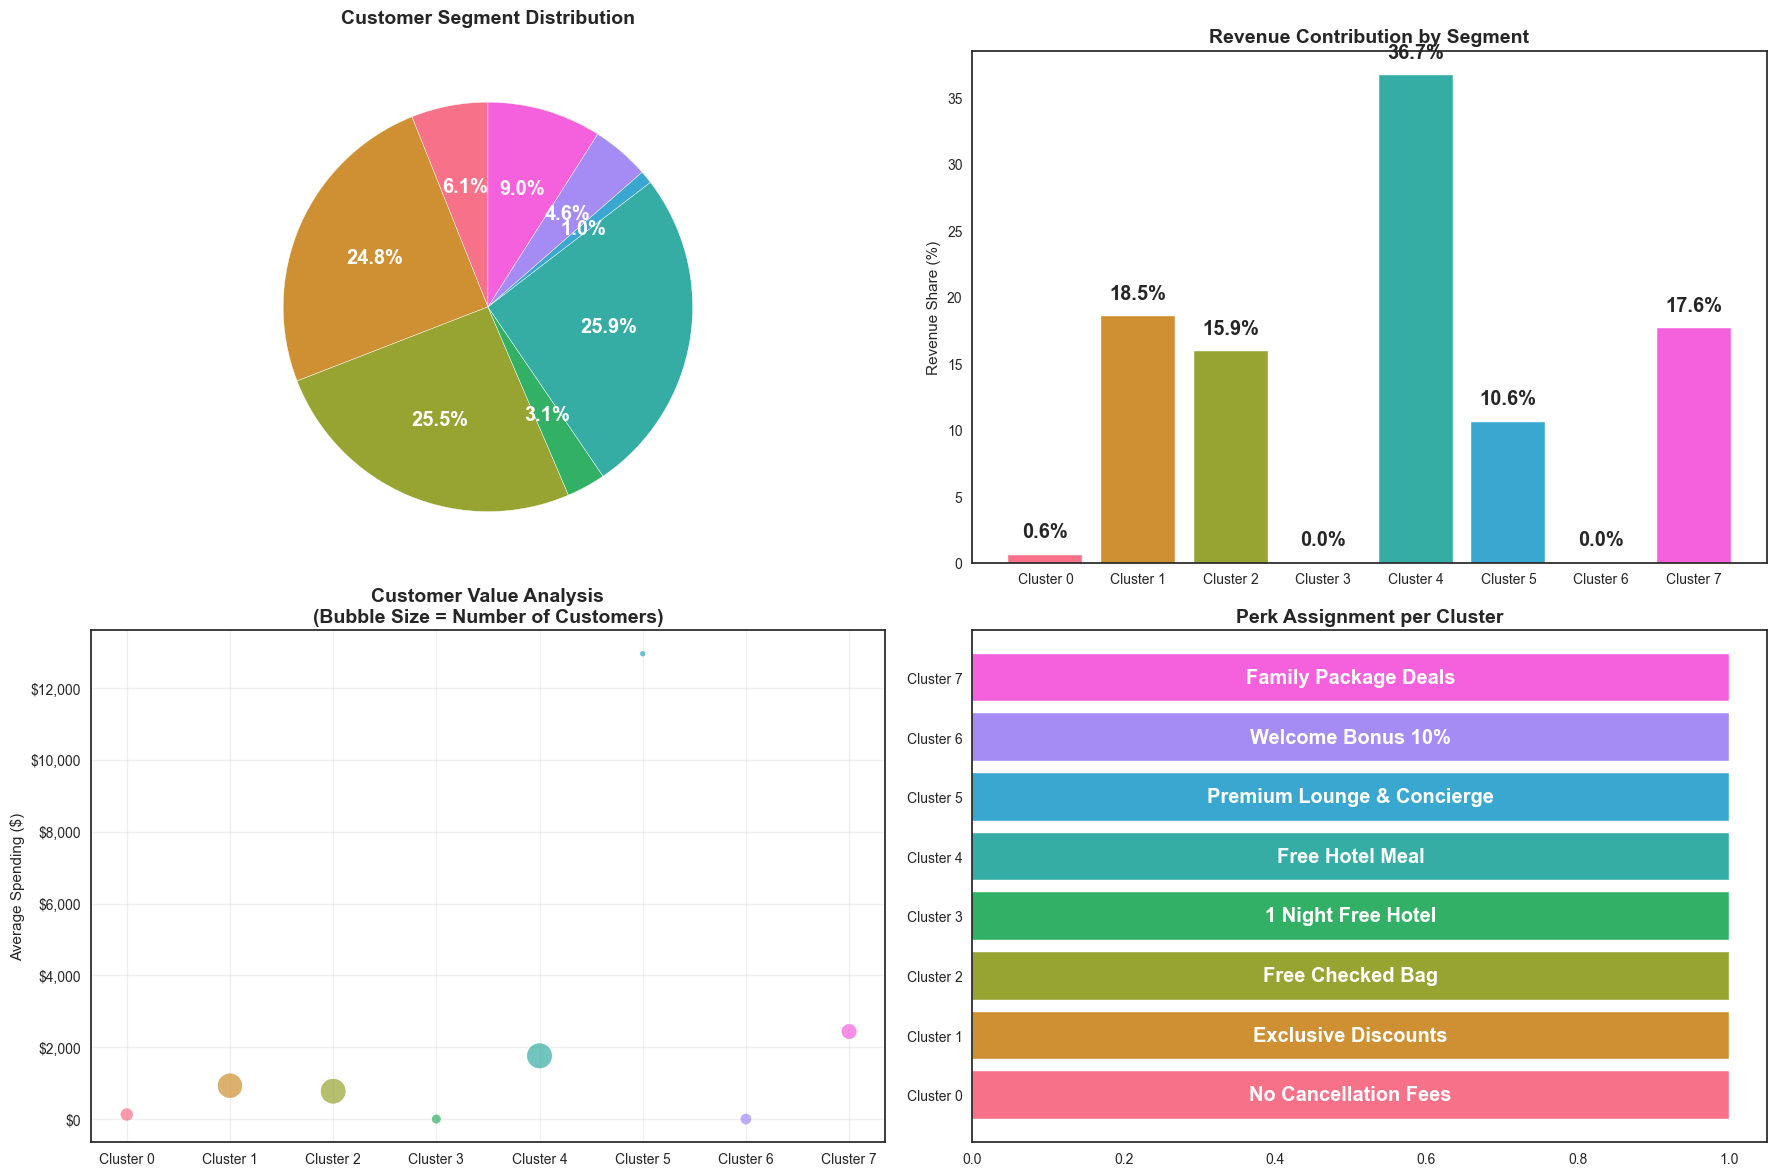

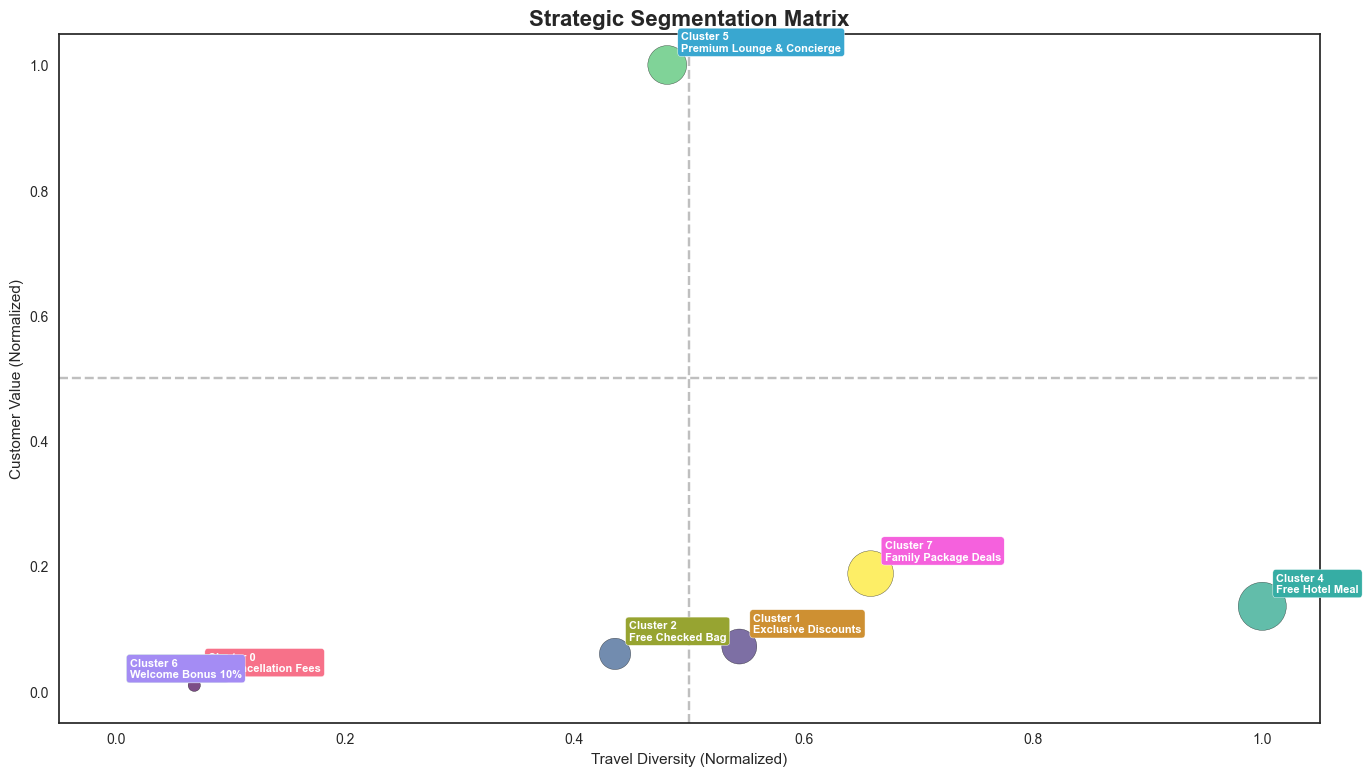

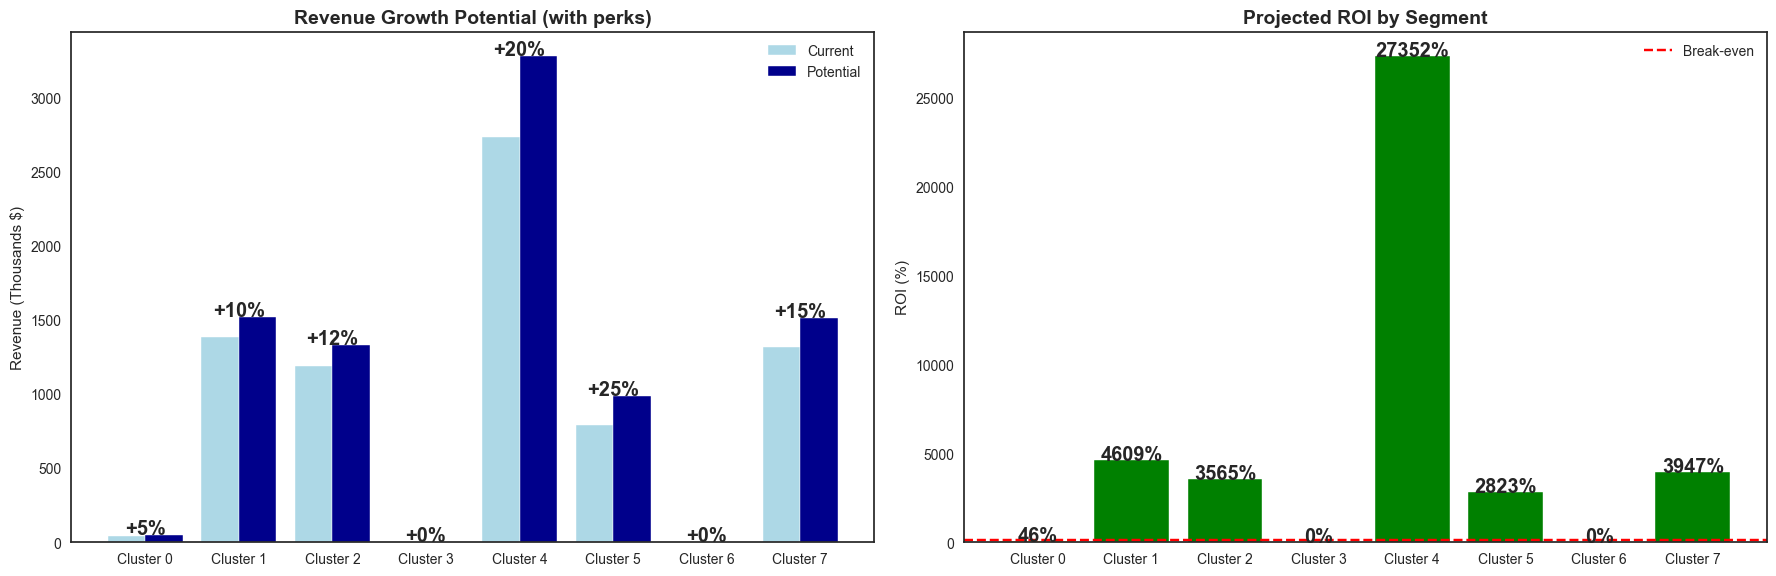

📊 EXECUTIVE SUMMARY DASHBOARD

Total Customers: 5,998
Total Revenue: $7,458,043
Average Customer Value: $1,243
Customer Segments: 8

Cluster 0:
  • Customers: 363 (0.6% of revenue)
  • Avg Spend: $126
  • Destinations: 0.3
  • Perk: No Cancellation Fees
  • Goal: Build trust with flexible policies

Cluster 1:
  • Customers: 1,490 (18.5% of revenue)
  • Avg Spend: $928
  • Destinations: 2.0
  • Perk: Exclusive Discounts
  • Goal: Increase engagement with deals

Cluster 2:
  • Customers: 1,532 (15.9% of revenue)
  • Avg Spend: $776
  • Destinations: 1.6
  • Perk: Free Checked Bag
  • Goal: Retain family/high-baggage travelers

Cluster 3:
  • Customers: 184 (0.0% of revenue)
  • Avg Spend: $0
  • Destinations: 0.0
  • Perk: 1 Night Free Hotel
  • Goal: Boost loyalty with premium bundles

Cluster 4:
  • Customers: 1,554 (36.7% of revenue)
  • Avg Spend: $1,760
  • Destinations: 3.7
  • Perk: Free Hotel Meal
  • Goal: Encourage hotel loyalty

Cluster 5:
  • Customers: 61 (10.6% of revenue)


In [23]:
# ============================================
# CLUSTER STORYTELLING & BUSINESS DASHBOARD
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Styling
plt.style.use('seaborn-v0_8-white')
sns.set_palette("husl")
PRESENTATION_COLORS = sns.color_palette("husl", 8)

# -------------------------------
# CONFIGURATION
# -------------------------------
perk_assignments = {
    0: "No Cancellation Fees",
    1: "Exclusive Discounts",
    2: "Free Checked Bag",
    3: "1 Night Free Hotel",
    4: "Free Hotel Meal",
    5: "Premium Lounge & Concierge",
    6: "Welcome Bonus 10%",
    7: "Family Package Deals"
}

def get_business_goal(cluster_id):
    goals = {
        0: "Build trust with flexible policies",
        1: "Increase engagement with deals",
        2: "Retain family/high-baggage travelers",
        3: "Boost loyalty with premium bundles",
        4: "Encourage hotel loyalty",
        5: "Maximize value from ultra-premium travelers",
        6: "Activate inactive customers",
        7: "Upsell families & group travelers"
    }
    return goals.get(cluster_id, "Drive engagement")

growth_factors = {
    0: 1.05, 1: 1.10, 2: 1.12, 3: 1.15,
    4: 1.20, 5: 1.25, 6: 1.08, 7: 1.15
}

# -------------------------------
# 1. EXECUTIVE SUMMARY - CLUSTER OVERVIEW
# -------------------------------
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# A. Customer Distribution
cluster_sizes = df_clusters['cluster'].value_counts().sort_index()
ax1.pie(cluster_sizes.values,
        labels=[f'Cluster {i}' for i in cluster_sizes.index],
        autopct='%1.1f%%',
        colors=PRESENTATION_COLORS,
        startangle=90,
        textprops={'color':'white','weight':'bold'})
ax1.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold', pad=20)

# B. Revenue Contribution
revenue_by_cluster = df_clusters.groupby('cluster')['total_flight_fare_usd'].sum()
revenue_share = (revenue_by_cluster / revenue_by_cluster.sum()) * 100
bars = ax2.bar(range(len(revenue_share)), revenue_share.values, color=PRESENTATION_COLORS)
ax2.set_title('Revenue Contribution by Segment', fontsize=14, fontweight='bold')
ax2.set_ylabel('Revenue Share (%)')
ax2.set_xticks(range(len(revenue_share)))
ax2.set_xticklabels([f'Cluster {i}' for i in revenue_share.index])
for bar, value in zip(bars, revenue_share.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

# C. Customer Value (Bubble)
avg_spending = df_clusters.groupby('cluster')['total_flight_fare_usd'].mean()
customer_counts = df_clusters['cluster'].value_counts().sort_index()
ax3.scatter(range(len(avg_spending)), avg_spending.values,
            s=customer_counts.values/5, alpha=0.7, color=PRESENTATION_COLORS)
ax3.set_title('Customer Value Analysis\n(Bubble Size = Number of Customers)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Average Spending ($)')
ax3.set_xticks(range(len(avg_spending)))
ax3.set_xticklabels([f'Cluster {i}' for i in avg_spending.index])
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
ax3.grid(True, alpha=0.3)

# D. Perk Overview
y_pos = np.arange(len(perk_assignments))
ax4.barh(y_pos, [1]*len(perk_assignments), color=PRESENTATION_COLORS)
ax4.set_yticks(y_pos)
ax4.set_yticklabels([f'Cluster {i}' for i in perk_assignments.keys()])
ax4.set_title('Perk Assignment per Cluster', fontsize=14, fontweight='bold')
for i,(cluster,perk) in enumerate(perk_assignments.items()):
    ax4.text(0.5, i, perk, ha='center', va='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

# -------------------------------
# 2. STRATEGIC INSIGHT - CUSTOMER MATRIX
# -------------------------------
fig, ax = plt.subplots(figsize=(14, 8))
matrix_data = df_clusters.groupby('cluster').agg({
    'total_flight_fare_usd':'mean',
    'n_unique_destinations':'mean',
    'total_flights_booked':'mean'
})
matrix_norm = (matrix_data - matrix_data.min()) / (matrix_data.max()-matrix_data.min())
scatter = ax.scatter(matrix_norm['n_unique_destinations'],
                    matrix_norm['total_flight_fare_usd'],
                    s=matrix_norm['total_flights_booked']*1200,
                    c=range(len(matrix_norm)), cmap='viridis', alpha=0.7, edgecolors='black')
ax.axhline(y=0.5, color='gray', ls='--', alpha=0.5)
ax.axvline(x=0.5, color='gray', ls='--', alpha=0.5)
for cid,row in matrix_norm.iterrows():
    ax.annotate(f'Cluster {cid}\n{perk_assignments[cid]}',
                xy=(row['n_unique_destinations'],row['total_flight_fare_usd']),
                xytext=(10,10), textcoords='offset points',
                bbox=dict(boxstyle="round,pad=0.3", facecolor=PRESENTATION_COLORS[cid]),
                color='white', weight='bold', fontsize=8)
ax.set_xlabel('Travel Diversity (Normalized)')
ax.set_ylabel('Customer Value (Normalized)')
ax.set_title('Strategic Segmentation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------
# 3. BUSINESS IMPACT - REVENUE POTENTIAL
# -------------------------------
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(18,6))
current_revenue = revenue_by_cluster
potential_revenue = current_revenue * pd.Series(growth_factors)
x = np.arange(len(current_revenue))
bars1=ax1.bar(x-0.2,current_revenue.values/1000,0.4,label='Current',color='lightblue')
bars2=ax1.bar(x+0.2,potential_revenue.values/1000,0.4,label='Potential',color='darkblue')
ax1.set_title('Revenue Growth Potential (with perks)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Revenue (Thousands $)')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Cluster {i}' for i in current_revenue.index])
ax1.legend()
for i,(c,p) in enumerate(zip(current_revenue,potential_revenue)):
    growth_pct=((p-c)/c)*100 if c>0 else 0
    ax1.text(i,max(c,p)/1000+5,f'+{growth_pct:.0f}%',ha='center',weight='bold')

implementation_costs=[5000,3000,4000,6000,2000,7000,2000,5000]
additional_revenue=potential_revenue-current_revenue
roi=(additional_revenue/implementation_costs)*100
bars=ax2.bar(range(len(roi)),roi.values,color=['green' if x>100 else 'orange' for x in roi])
ax2.axhline(y=100,color='red',ls='--',label='Break-even')
ax2.set_title('Projected ROI by Segment',fontsize=14,fontweight='bold')
ax2.set_ylabel('ROI (%)')
ax2.set_xticks(range(len(roi)))
ax2.set_xticklabels([f'Cluster {i}' for i in roi.index])
ax2.legend()
for bar,val in zip(bars,roi.values):
    ax2.text(bar.get_x()+bar.get_width()/2,val+5,f'{val:.0f}%',ha='center',weight='bold')

plt.tight_layout()
plt.show()

# -------------------------------
# 4. EXECUTIVE DASHBOARD
# -------------------------------
print("="*80)
print("📊 EXECUTIVE SUMMARY DASHBOARD")
print("="*80)

total_customers=len(df_clusters)
total_revenue=df_clusters['total_flight_fare_usd'].sum()
print(f"\nTotal Customers: {total_customers:,}")
print(f"Total Revenue: ${total_revenue:,.0f}")
print(f"Average Customer Value: ${total_revenue/total_customers:,.0f}")
print(f"Customer Segments: {df_clusters['cluster'].nunique()}")

for cid in sorted(df_clusters['cluster'].unique()):
    cdata=df_clusters[df_clusters['cluster']==cid]
    revenue=cdata['total_flight_fare_usd'].sum()
    share=(revenue/total_revenue)*100
    print(f"\nCluster {cid}:")
    print(f"  • Customers: {len(cdata):,} ({share:.1f}% of revenue)")
    print(f"  • Avg Spend: ${cdata['total_flight_fare_usd'].mean():,.0f}")
    print(f"  • Destinations: {cdata['n_unique_destinations'].mean():.1f}")
    print(f"  • Perk: {perk_assignments[cid]}")
    print(f"  • Goal: {get_business_goal(cid)}")

# Export
executive_summary=pd.DataFrame({
    'Cluster':[f'Cluster {i}' for i in sorted(df_clusters['cluster'].unique())],
    'Customer_Count':[len(df_clusters[df_clusters['cluster']==i]) for i in sorted(df_clusters['cluster'].unique())],
    'Avg_Spending':[df_clusters[df_clusters['cluster']==i]['total_flight_fare_usd'].mean() for i in sorted(df_clusters['cluster'].unique())],
    'Revenue_Share_%':[(df_clusters[df_clusters['cluster']==i]['total_flight_fare_usd'].sum()/total_revenue*100) for i in sorted(df_clusters['cluster'].unique())],
    'Recommended_Perk':[perk_assignments[i] for i in sorted(df_clusters['cluster'].unique())],
    'Business_Goal':[get_business_goal(i) for i in sorted(df_clusters['cluster'].unique())]
})
executive_summary.to_csv("executive_summary_dashboard.csv", index=False)
print("\n✅ Saved as 'executive_summary_dashboard.csv'")